# 🧠 Fine-Tuning Transformers for Question Answering (SQuAD v1.1)
**Description:** This notebook demonstrates how Question Answering differs from classification tasks by fine-tuning a pre-trained BERT-based model on the SQuAD v1.1 dataset using Hugging Face. The model is then evaluated and tested on real-world questions.


> **Submitted by:** *Selim Ahmed*<br/>
> AI Engineering | Batch 1 |

## Install Required Libraries


In [35]:
!pip -q install transformers datasets evaluate accelerate

In [36]:
import transformers
print(transformers.__version__)
# from transformers import TrainingArguments
# help(TrainingArguments)

4.55.4


## Import Libraries

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import evaluate

from pprint import pprint
from collections import defaultdict, Counter

from transformers import AutoTokenizer, AutoModelForQuestionAnswering, TrainingArguments, Trainer, default_data_collator

## Load dataset

In [38]:
from datasets import load_dataset

dataset = load_dataset("squad")
metric = evaluate.load("squad")

## Exploratory Data Analysis (EDA)

Dataset Columns

In [39]:
df_train = pd.DataFrame(dataset["train"][:2000])
df_train.head()

,id,title,context,question,answers
0,5733be284776f41900661182,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,"{'text': ['Saint Bernadette Soubirous'], 'answ..."
1,5733be284776f4190066117f,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,"{'text': ['a copper statue of Christ'], 'answe..."
2,5733be284776f41900661180,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,"{'text': ['the Main Building'], 'answer_start'..."
3,5733be284776f41900661181,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is the Grotto at Notre Dame?,{'text': ['a Marian place of prayer and reflec...
4,5733be284776f4190066117e,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What sits on top of the Main Building at Notre...,{'text': ['a golden statue of the Virgin Mary'...


Data & Number of Samples

In [40]:
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("\n----------------------------------\n")
print(dataset['train'].column_names)
print("\n----------------------------------\n")
sample = dataset["train"][0]
for k, v in sample.items():
    print(f"{k}: {v if k != 'context' else v[:300] + '...'}")

Train size: 87599
Validation size: 10570

----------------------------------

['id', 'title', 'context', 'question', 'answers']

----------------------------------

id: 5733be284776f41900661182
title: University_of_Notre_Dame
context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is ...
question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
answers: {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


Question Length Distribution

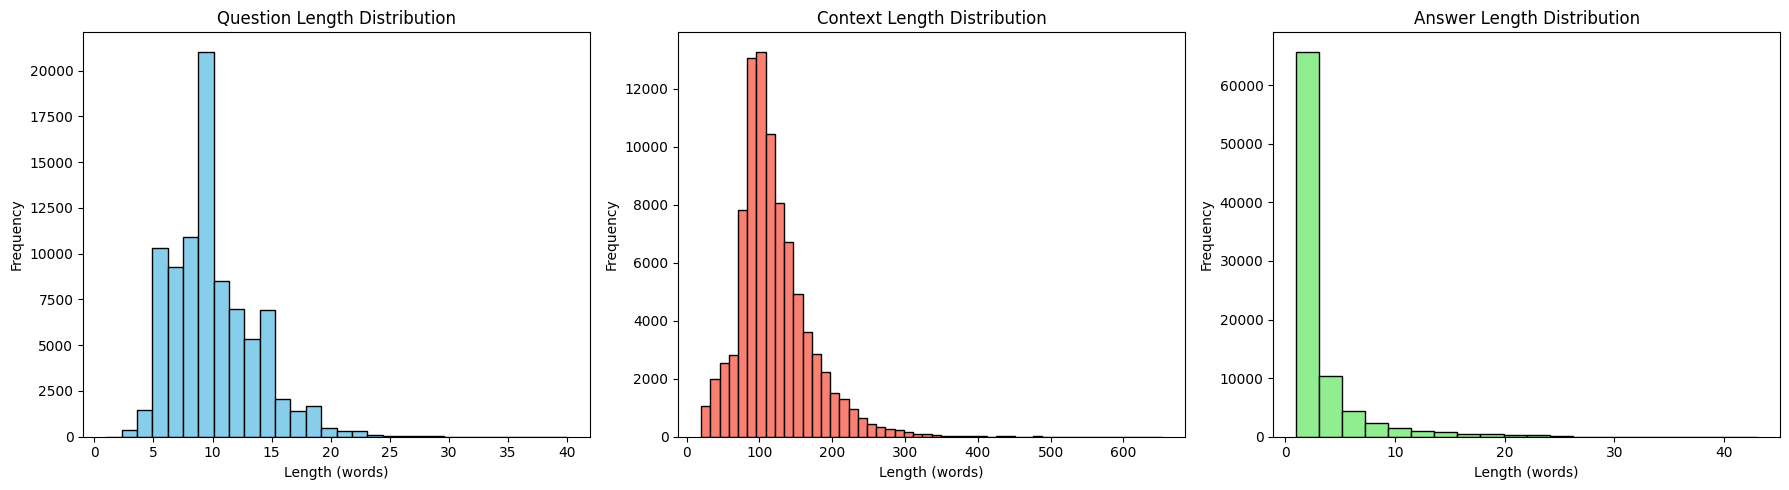

In [41]:
# Compute lengths
q_lens = [len(q.split()) for q in dataset["train"]["question"]]
c_lens = [len(c.split()) for c in dataset["train"]["context"]]
a_lens = [len(ans["text"][0].split()) for ans in dataset["train"]["answers"]]

# Plot with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Question Length Distribution
axes[0].hist(q_lens, bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Question Length Distribution")
axes[0].set_xlabel("Length (words)")
axes[0].set_ylabel("Frequency")

# Context Length Distribution
axes[1].hist(c_lens, bins=50, color="salmon", edgecolor="black")
axes[1].set_title("Context Length Distribution")
axes[1].set_xlabel("Length (words)")
axes[1].set_ylabel("Frequency")

# Answer Length Distribution
axes[2].hist(a_lens, bins=20, color="lightgreen", edgecolor="black")
axes[2].set_title("Answer Length Distribution")
axes[2].set_xlabel("Length (words)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


Common Question Words

In [42]:
first_words = [q.split()[0].lower() for q in dataset["train"]["question"]]
counter = Counter(first_words)
print(counter.most_common(10))

print("\n----------------------------------\n")

for q in dataset["train"]["question"][:10]:
    if q.lower().startswith(("who", "what", "when", "where")):
        print(q)

[('what', 37593), ('who', 8150), ('how', 8124), ('when', 5459), ('in', 4352), ('which', 4159), ('where', 3291), ('the', 2318), ('why', 1201), ('on', 590)]

----------------------------------

What is in front of the Notre Dame Main Building?
What is the Grotto at Notre Dame?
What sits on top of the Main Building at Notre Dame?
When did the Scholastic Magazine of Notre dame begin publishing?
What is the daily student paper at Notre Dame called?


## Tokenization

### Initial Model Declaration

In [43]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)

# Hyperparameters for max length + stride (standard choices for SQuAD-style QA)
max_length = 384
doc_stride = 128

pad_on_right = tokenizer.padding_side == "right"

### Prepare Train Features

In [44]:
def prepare_train_features(examples):
    tokenized_train = tokenizer(
        examples["question" if pad_on_right else "context"],
        examples["context" if pad_on_right else "question"],
        truncation="only_second" if pad_on_right else "only_first",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_train.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized_train.pop("offset_mapping")

   # Initialize labels
    tokenized_train["start_positions"] = []
    tokenized_train["end_positions"] = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized_train["input_ids"][i]
        # The index of the example containing this feature
        sample_idx = sample_mapping[i]
        answers = examples["answers"][sample_idx]

        if len(answers["answer_start"]) == 0:
            # No answer: set cls_index
            tokenized_train["start_positions"].append(0)
            tokenized_train["end_positions"].append(0)
        else:
            # Start/end character index of the answer in the text
            start_char = answers["answer_start"][0]
            end_char = start_char + len(answers["text"][0])

            # Find the start and end token indices in the feature
            sequence_ids = tokenized_train.sequence_ids(i)

            # Find the token start index of the context
            token_start_index = 0
            while sequence_ids[token_start_index] != 1:
                token_start_index += 1

            token_end_index = len(input_ids) - 1
            while sequence_ids[token_end_index] != 1:
                token_end_index -= 1

            # If the answer is out of the span (in this feature), label it (0, 0)
            if not (offsets[token_start_index][0] <= start_char and offsets[token_end_index][1] >= end_char):
                tokenized_train["start_positions"].append(0)
                tokenized_train["end_positions"].append(0)
            else:
                # Otherwise move the token_start_index and token_end_index to the two ends of the answer
                while token_start_index < len(offsets) and offsets[token_start_index][0] <= start_char:
                    token_start_index += 1
                start_position = token_start_index - 1

                while offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                end_position = token_end_index + 1

                tokenized_train["start_positions"].append(start_position)
                tokenized_train["end_positions"].append(end_position)

    return tokenized_train

### Prepare Validation Features

In [45]:
def prepare_validation_features(examples):
    tokenized_validation = tokenizer(
        examples["question" if pad_on_right else "context"],
        examples["context" if pad_on_right else "question"],
        truncation="only_second" if pad_on_right else "only_first",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_validation.pop("overflow_to_sample_mapping")
    tokenized_validation["example_id"] = []

    for i in range(len(tokenized_validation["input_ids"])):
        sample_index = sample_mapping[i]
        tokenized_validation["example_id"].append(examples["id"][sample_index])

        sequence_ids = tokenized_validation.sequence_ids(i)

        context_index = 1 if pad_on_right else 0
        offsets = tokenized_validation["offset_mapping"][i]

        tokenized_validation["offset_mapping"][i] = [
            (o if sequence_ids[k] == context_index else None) for k, o in enumerate(offsets)
        ]

    return tokenized_validation

# Apply to validation dataset
validation_features = dataset["validation"].map(
    prepare_validation_features,
    batched=True,  # important fix
    remove_columns=dataset["validation"].column_names,
)

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

### Running tokenizer on train/validation dataset

In [46]:
train_dataset = dataset["train"].map(
    prepare_train_features,
    batched=True,
    remove_columns=dataset["train"].column_names,
    desc="Running tokenizer on train dataset"
)

validation_dataset = dataset["validation"].map(
    prepare_validation_features,
    batched=True,
    remove_columns=dataset["validation"].column_names,
    desc="Running tokenizer on validation dataset"
)

len(train_dataset), len(validation_dataset)

Running tokenizer on validation dataset:   0%|          | 0/10570 [00:00<?, ? examples/s]

(88524, 10784)

## Model Setup

In [47]:
model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)
model.resize_token_embeddings(len(tokenizer))

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(30522, 768, padding_idx=0)

## Fine-tuning with `Trainer`

In [49]:
os.environ["WANDB_DISABLED"] = "true"

train_dataset = dataset["train"].map(
    prepare_train_features,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

training_args = TrainingArguments(
    output_dir="./qa-bert-squad",
    #evaluation_strategy="no", # we'll run a custom evaluation later
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    logging_steps=200,
    push_to_hub=False,
)


trainer = Trainer(
    model=model,
    args=training_args,
    # train_dataset=train_dataset,
    # eval_dataset=validation_features,
    train_dataset=train_dataset.select(range(2000)),
    eval_dataset=validation_features.select(range(500)),
    tokenizer=tokenizer,
    data_collator=default_data_collator,
)


# Start training
trainer.train()


# Save final model
trainer.save_model("./qa-bert-squad-final")

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-329819628.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
200,3.147300


## Evaluation — Exact Match (EM) & F1

In [50]:
from collections import OrderedDict
import numpy as np

def postprocess_qa_predictions(examples, features, raw_predictions, n_best_size=20, max_answer_length=30):
    """
    Post-processes the predictions of a question-answering model to convert them to answers in text form.
    """
    all_start_logits, all_end_logits = raw_predictions

    # Build a map example id -> features
    example_id_to_index = {example["id"]: i for i, example in enumerate(examples)}
    features_per_example = OrderedDict()
    for i, feature in enumerate(features):
        example_id = feature["example_id"]
        features_per_example.setdefault(example_id, []).append(i)

    predictions = OrderedDict()

    for example in examples:
        example_id = example["id"]
        context = example["context"]
        feature_indices = features_per_example.get(example_id, [])

        prelim_predictions = []

        # Loop through all features associated with this example
        for feature_index in feature_indices:
            start_logits = all_start_logits[feature_index]
            end_logits = all_end_logits[feature_index]
            offsets = features[feature_index]["offset_mapping"]

            # Get top n_best_size start and end logits
            start_indexes = np.argsort(start_logits)[-1: -n_best_size - 1: -1].tolist()
            end_indexes = np.argsort(end_logits)[-1: -n_best_size - 1: -1].tolist()

            for start_index in start_indexes:
                for end_index in end_indexes:
                    # Skip answers that are not in the context
                    if start_index >= len(offsets) or end_index >= len(offsets):
                        continue
                    if offsets[start_index] is None or offsets[end_index] is None:
                        continue
                    if end_index < start_index:
                        continue
                    length = end_index - start_index + 1
                    if length > max_answer_length:
                        continue

                    prelim_predictions.append({
                        "offsets": (offsets[start_index][0], offsets[end_index][1]),
                        "score": start_logits[start_index] + end_logits[end_index],
                        "start_logit": start_logits[start_index],
                        "end_logit": end_logits[end_index],
                    })

        if len(prelim_predictions) == 0:
            predictions[example_id] = ""
            continue

        best_pred = sorted(prelim_predictions, key=lambda x: x["score"], reverse=True)[0]
        start_char, end_char = best_pred["offsets"]
        predictions[example_id] = context[start_char: end_char]

    return predictions

In [51]:
# Run prediction on validation features
raw_pred = trainer.predict(validation_features)

# Unpack tuple
all_start_logits, all_end_logits = raw_pred.predictions

# Convert features dataset to a list of dicts for postprocessing
features_for_post = [
    {"offset_mapping": f["offset_mapping"], "example_id": f["example_id"]}
    for f in validation_features
]

# Build examples list needed by postprocessing
examples_for_post = [
    {"id": e["id"], "context": e["context"]}
    for e in dataset["validation"]
]

# We need the original validation examples to build references
validation_examples = dataset["validation"]

# Postprocess predictions
predicted_answers = postprocess_qa_predictions(
    examples_for_post, features_for_post, (all_start_logits, all_end_logits)
)


# Build references list for metric
references = [{"id": ex["id"], "answers": ex["answers"]} for ex in validation_examples]

metrics = metric.compute(predictions=[{"id": k, "prediction_text": v} for k, v in predicted_answers.items()], references=references)
metrics

{'exact_match': 41.60832544938505, 'f1': 53.34614915222453}

## Real-World Q&A Tests

In [52]:
question_answering_model = model
qa_tokenizer = tokenizer

def answer_question(question, context, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    question_answering_model.to(device)

    inputs = qa_tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=384,
        stride=64,
        return_offsets_mapping=True,
        padding="max_length"
    )

    # Keep offset mapping before moving tensors to GPU
    offset_mapping = inputs.pop("offset_mapping")[0].tolist()
    sequence_ids = inputs.sequence_ids(0)

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = question_answering_model(**inputs)

    start_logits = outputs.start_logits[0].cpu()
    end_logits = outputs.end_logits[0].cpu()

    start_idx = torch.argmax(start_logits).item()
    end_idx = torch.argmax(end_logits).item()

    # Ensure the predicted span is inside the context
    if sequence_ids[start_idx] != 1 or sequence_ids[end_idx] != 1:
        return "[No Answer Found]"

    start_char, _ = offset_mapping[start_idx]
    _, end_char = offset_mapping[end_idx]

    if start_char is None or end_char is None or start_char >= end_char:
        return "[No Answer Found]"

    return context[start_char:end_char]

In [53]:
#Evaluation: Custom Questions
# =========================

q1 = "What is the tallest mountain in the world?"
c1 = "Mount Everest, located in the Himalayas, is the tallest mountain in the world."
print("Q1:", q1)
print("A1:", answer_question(q1, c1))
q2 = "Who painted the Mona Lisa?"
c2 = "The Mona Lisa is a famous portrait painting created by Leonardo da Vinci during the Italian Renaissance."
print("\n")
print("Q2:", q2)
print("A2:", answer_question(q2, c2))
q3 = "Who is known as the father of computers?"
c3 = "Charles Babbage is often referred to as the father of computers due to his work on the Analytical Engine."
print("\n")
print("Q2:", q3)
print("A2:", answer_question(q3, c3))

Q1: What is the tallest mountain in the world?
A1: Mount Everest


Q2: Who painted the Mona Lisa?
A2: Leonardo da Vinci


Q2: Who is known as the father of computers?
A2: Charles Babbage


## ✨ Reflection (5–6 sentences)
- In this assignment, I learned how extractive QA differs from text classification, especially the need to map character-level answers to token spans.  
- I practiced sliding windows with `doc_stride` to handle long contexts and how to post-process logits into readable answers.  
- I explored evaluation using **Exact Match** and **F1**, which compare predicted answer strings to ground-truth spans.  
- Training with Hugging Face `Trainer` simplified the pipeline from data to model to evaluation.  
- If I extended this work, I would experiment with better pre-trained checkpoints (e.g., `distilbert-base-uncased`, `deberta-base`), larger `max_length`, and more robust decoding (n-best lists).  
- I also learned about the importance of **tokenizer alignment** and why span indices can become tricky after subword tokenization.